Eksploracyjna Analiza Danych (EDA)
Cel tego notebooka
Przed budową modelu predykcyjnego musimy zrozumieć dane którymi dysponujemy.
EDA odpowiada na pytania: ile mamy danych, jak są rozłożone, czy są kompletne,
jakie zależności między nimi istnieją.
Pracujemy na zbiorze MovieLens 1M — 1 000 209 rzeczywistych ocen filmów
wystawionych przez 6 040 użytkowników na 3 883 filmach.

📄 Szczegółowy opis zbioru danych i uzasadnienie jego wyboru: docs/01_eda.md

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

Wczytanie danych
Pliki MovieLens używają separatora :: zamiast standardowego przecinka.
Plik movies.dat wymaga kodowania latin-1 ze względu na znaki specjalne w tytułach.
Trzy pliki źródłowe:

ratings.dat — kto, co i jak ocenił
movies.dat — tytuły i gatunki filmów
users.dat — dane demograficzne użytkowników

In [2]:
ratings = pd.read_csv(
    '../data/ratings.dat',
    sep='::',
    engine='python',
    names=['userId', 'movieId', 'rating', 'timestamp']
)

movies = pd.read_csv(
    '../data/movies.dat',
    sep='::',
    engine='python',
    names=['movieId', 'title', 'genres'],
    encoding='latin-1'
)

users = pd.read_csv(
    '../data/users.dat',
    sep='::',
    engine='python',
    names=['userId', 'gender', 'age', 'occupation', 'zip']
)

print("ratings:", ratings.shape)
print("movies:", movies.shape)
print("users:", users.shape)

ratings: (1000209, 4)
movies: (3883, 3)
users: (6040, 5)


Podgląd danych
Sprawdzamy czy dane wczytały się poprawnie — kolumny mają właściwe nazwy,
wartości wyglądają sensownie, typy danych są odpowiednie.

In [3]:
display(ratings.head(3))
display(movies.head(3))
display(users.head(3))

,userId,movieId,rating,timestamp
0,1,1193,5,978300760
1,1,661,3,978302109
2,1,914,3,978301968


,movieId,title,genres
0,1,Toy Story (1995),Animation|Children's|Comedy
1,2,Jumanji (1995),Adventure|Children's|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance


,userId,gender,age,occupation,zip
0,1,F,1,10,48067
1,2,M,56,16,70072
2,3,M,25,15,55117


Rozkład ocen
Histogram pokazuje jak często użytkownicy wystawiali każdą z ocen (1–5).
Oczekiwany wzorzec: dominacja ocen 3–5 (tzw. selection bias — użytkownicy
chętniej oceniają filmy które lubią). Ma to bezpośredni wpływ na zachowanie modelu.

📄 Szczegółowa interpretacja i wpływ na model: docs/01_eda.md → sekcja "Celka 4"

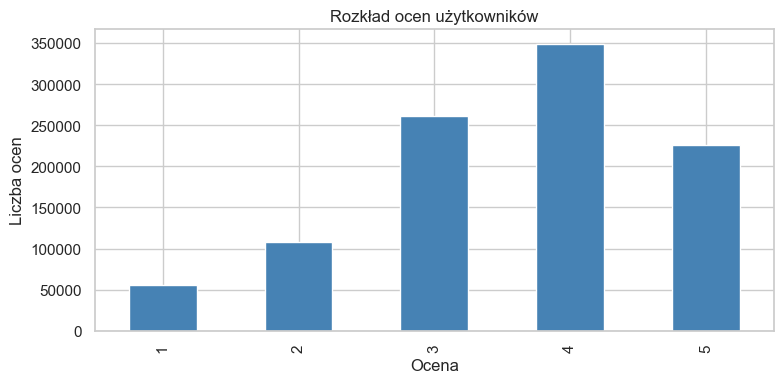

In [4]:
plt.figure(figsize=(8, 4))
ratings['rating'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('Rozkład ocen użytkowników')
plt.xlabel('Ocena')
plt.ylabel('Liczba ocen')
plt.tight_layout()
plt.savefig('../notebooks/plot_rating_distribution.png', dpi=150)
plt.show()

Statystyki opisowe
Zestaw liczb charakteryzujących rozkład zmiennych: średnia, mediana,
odchylenie standardowe, wartości min/max i kwartyle.
Kluczowa obserwacja: średnia ocena (~3.58) jest niższa od mediany (~4.0)
co potwierdza skośność rozkładu opisaną powyżej.

In [5]:
print("=== RATINGS ===")
print(ratings['rating'].describe())
print("\n=== USERS ===")
print(users[['age', 'occupation']].describe())
print("\nPłeć:", users['gender'].value_counts().to_dict())

=== RATINGS ===
count    1.000209e+06
mean     3.581564e+00
std      1.117102e+00
min      1.000000e+00
25%      3.000000e+00
50%      4.000000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64

=== USERS ===
               age   occupation
count  6040.000000  6040.000000
mean     30.639238     8.146854
std      12.895962     6.329511
min       1.000000     0.000000
25%      25.000000     3.000000
50%      25.000000     7.000000
75%      35.000000    14.000000
max      56.000000    20.000000

Płeć: {'M': 4331, 'F': 1709}


Aktywność użytkowników
Sprawdzamy ile ocen wystawił każdy użytkownik.
Rozkład jest silnie prawostronnie skośny — większość użytkowników wystawiła
stosunkowo mało ocen, ale istnieje niewielka grupa bardzo aktywnych użytkowników.
To typowy wzorzec w serwisach społecznościowych (prawo Pareto).

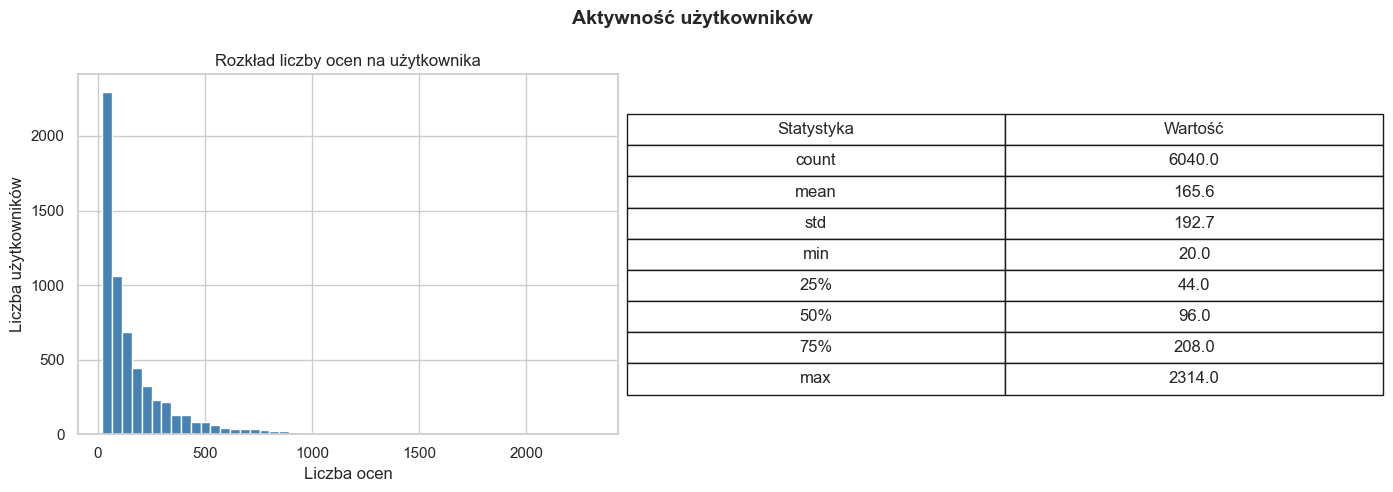

In [6]:
user_activity = ratings.groupby('userId')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(user_activity, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Rozkład liczby ocen na użytkownika')
axes[0].set_xlabel('Liczba ocen')
axes[0].set_ylabel('Liczba użytkowników')

# statystyki jako tabela
stats = user_activity.describe().round(1)
table_data = [[idx, val] for idx, val in stats.items()]
axes[1].axis('off')
table = axes[1].table(
    cellText=table_data,
    colLabels=['Statystyka', 'Wartość'],
    cellLoc='center',
    loc='center'
)
table.set_fontsize(12)
table.scale(1.4, 2.0)

plt.suptitle('Aktywność użytkowników', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plot_user_activity.png', dpi=150)
plt.show()

Popularność filmów
Analizujemy liczbę ocen i średnią ocenę dla każdego filmu.
Popularność (liczba ocen) ≠ Jakość (średnia ocena) — film może być
bardzo popularny i mieć przeciętną ocenę, bo oglądają go wszyscy, nie tylko fani.
Tabela Top 10 najpopularniejszych filmów będzie przydatna jako punkt odniesienia
przy interpretacji wyników modelu.

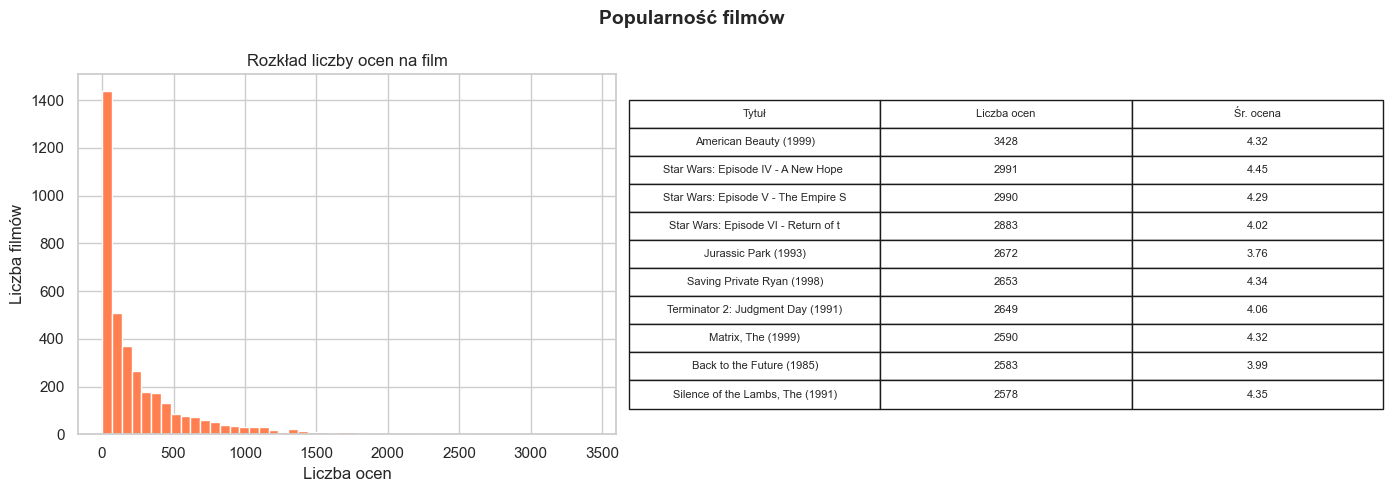

In [7]:
movie_popularity = ratings.groupby('movieId')['rating'].agg(['count', 'mean']).reset_index()
movie_popularity.columns = ['movieId', 'rating_count', 'rating_mean']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram
axes[0].hist(movie_popularity['rating_count'], bins=50, color='coral', edgecolor='white')
axes[0].set_title('Rozkład liczby ocen na film')
axes[0].set_xlabel('Liczba ocen')
axes[0].set_ylabel('Liczba filmów')

# top 10 najpopularniejszych filmów
top10 = (
    movie_popularity
    .merge(movies[['movieId', 'title']], on='movieId')
    .nlargest(10, 'rating_count')[['title', 'rating_count', 'rating_mean']]
    .reset_index(drop=True)
)
top10['title'] = top10['title'].str[:35]  # skróć długie tytuły
top10['rating_mean'] = top10['rating_mean'].round(2)

axes[1].axis('off')
table = axes[1].table(
    cellText=top10.values,
    colLabels=['Tytuł', 'Liczba ocen', 'Śr. ocena'],
    cellLoc='center',
    loc='center'
)
table.set_fontsize(10)
table.scale(1.4, 1.8)

plt.suptitle('Popularność filmów', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plot_movie_popularity.png', dpi=150)
plt.show()

Oceny według gatunku
Jeden film może należeć do wielu gatunków jednocześnie — dlatego najpierw
"rozkładamy" gatunki (explode) żeby każda para film–gatunek była osobnym wierszem.
Dwa wykresy:

Średnia ocena per gatunek — które gatunki są oceniane najwyżej?
Liczba ocen per gatunek — które gatunki są najpopularniejsze?

Gatunek będzie jedną z kluczowych zmiennych niezależnych w modelu.

📄 Interpretacja wyników i hipotezy badawcze: docs/01_eda.md → sekcja "Celka 8"

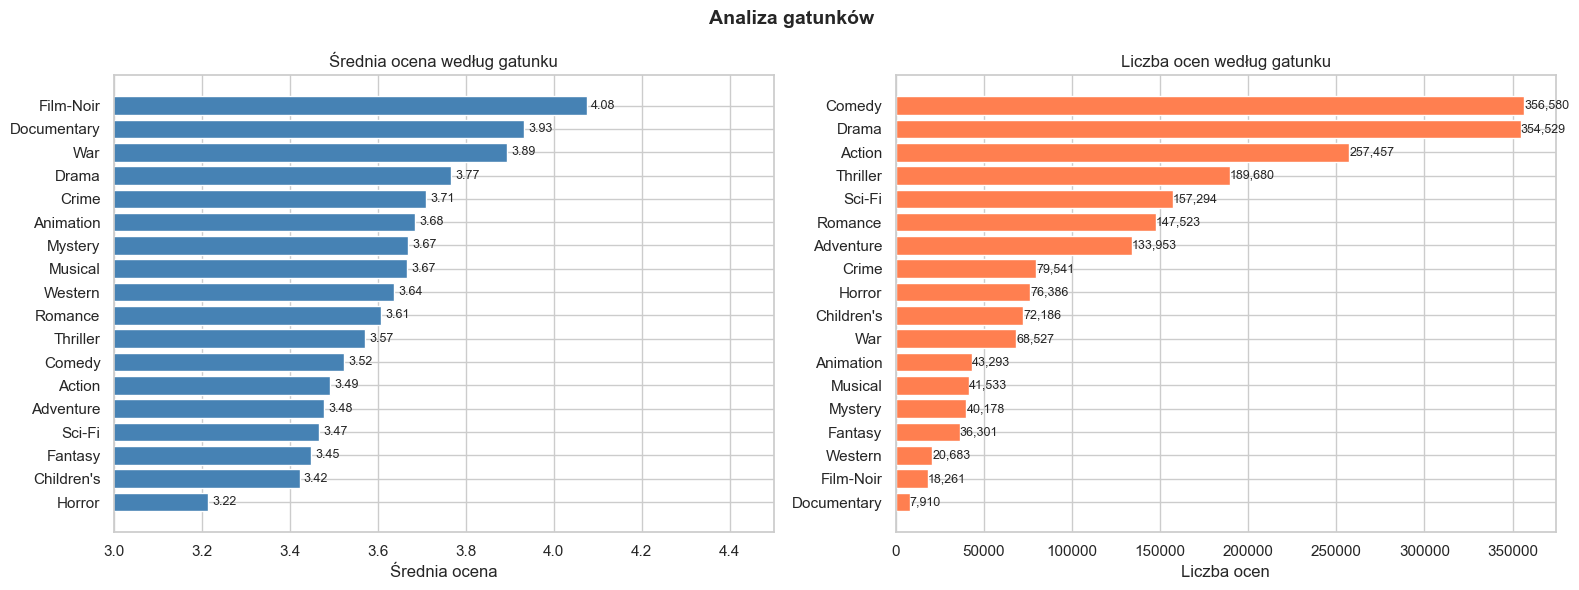

In [8]:
# rozbij gatunki (jeden film może mieć kilka)
movies_exploded = movies.copy()
movies_exploded['genres'] = movies_exploded['genres'].str.split('|')
movies_exploded = movies_exploded.explode('genres')

# połącz z ocenami
ratings_genres = ratings.merge(movies_exploded[['movieId', 'genres']], on='movieId')

# średnia ocena i liczba ocen per gatunek
genre_stats = ratings_genres.groupby('genres')['rating'].agg(['mean', 'count']).reset_index()
genre_stats.columns = ['genre', 'avg_rating', 'count']
genre_stats = genre_stats.sort_values('avg_rating', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# średnia ocena per gatunek
bars = axes[0].barh(genre_stats['genre'], genre_stats['avg_rating'], color='steelblue', edgecolor='white')
axes[0].set_title('Średnia ocena według gatunku')
axes[0].set_xlabel('Średnia ocena')
axes[0].set_xlim(3.0, 4.5)
for bar, val in zip(bars, genre_stats['avg_rating']):
    axes[0].text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}', va='center', fontsize=9)

# liczba ocen per gatunek
genre_stats_sorted = genre_stats.sort_values('count', ascending=True)
bars2 = axes[1].barh(genre_stats_sorted['genre'], genre_stats_sorted['count'], color='coral', edgecolor='white')
axes[1].set_title('Liczba ocen według gatunku')
axes[1].set_xlabel('Liczba ocen')
for bar, val in zip(bars2, genre_stats_sorted['count']):
    axes[1].text(val + 100, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=9)

plt.suptitle('Analiza gatunków', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plot_genres.png', dpi=150)
plt.show()

Demografia użytkowników
Analizujemy rozkład płci i wieku w zbiorze.
Ważne ograniczenie: MovieLens jest zdominowany przez mężczyzn (~72%).
Model może być mniej dokładny dla kobiet ze względu na niedoreprezentowanie
tej grupy w danych treningowych — opisujemy to w Rozdziale III pracy.

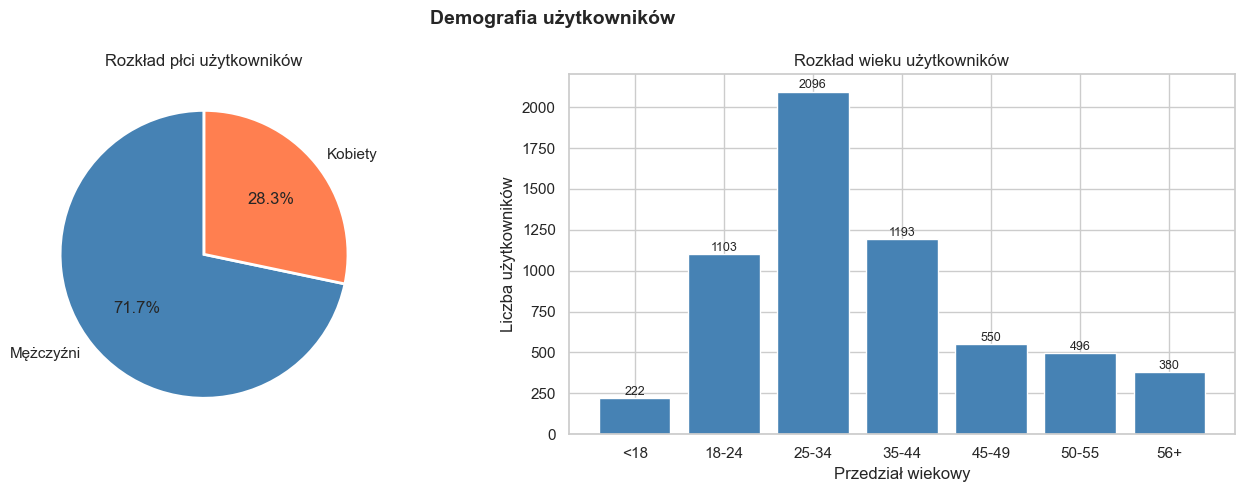

In [9]:
age_labels = {1: '<18', 18: '18-24', 25: '25-34', 35: '35-44', 45: '45-49', 50: '50-55', 56: '56+'}
users['age_label'] = users['age'].map(age_labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# płeć
gender_counts = users['gender'].value_counts()
axes[0].pie(
    gender_counts,
    labels=['Mężczyźni' if g == 'M' else 'Kobiety' for g in gender_counts.index],
    autopct='%1.1f%%',
    colors=['steelblue', 'coral'],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Rozkład płci użytkowników')

# wiek
age_order = ['<18', '18-24', '25-34', '35-44', '45-49', '50-55', '56+']
age_counts = users['age_label'].value_counts().reindex(age_order)
axes[1].bar(age_counts.index, age_counts.values, color='steelblue', edgecolor='white')
axes[1].set_title('Rozkład wieku użytkowników')
axes[1].set_xlabel('Przedział wiekowy')
axes[1].set_ylabel('Liczba użytkowników')
for i, val in enumerate(age_counts.values):
    axes[1].text(i, val + 20, str(val), ha='center', fontsize=9)

plt.suptitle('Demografia użytkowników', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/plot_demographics.png', dpi=150)
plt.show()

Zapis scalonych danych
Łączymy trzy tabele w jeden DataFrame operacją merge (odpowiednik JOIN z SQL):
ratings + users → łączymy po userId
wynik + movies  → łączymy po movieId
Wynik: jedna tabela gdzie każdy wiersz to ocena z pełnym kontekstem
(kto ocenił, co ocenił, jak ocenił). Zapisujemy do pliku jako punkt startowy
dla kolejnego etapu — preprocessingu.

In [10]:
# scal wszystko w jeden DataFrame — przyda się w preprocessing
df = ratings.merge(users, on='userId').merge(movies, on='movieId')
df.to_csv('../data/merged_raw.csv', index=False)
print(f"Zapisano: {df.shape[0]} wierszy, {df.shape[1]} kolumn")
display(df.head(3))

Zapisano: 1000209 wierszy, 11 kolumn


,userId,movieId,rating,timestamp,gender,age,occupation,zip,age_label,title,genres
0,1,1193,5,978300760,F,1,10,48067,<18,One Flew Over the Cuckoo's Nest (1975),Drama
1,1,661,3,978302109,F,1,10,48067,<18,James and the Giant Peach (1996),Animation|Children's|Musical
2,1,914,3,978301968,F,1,10,48067,<18,My Fair Lady (1964),Musical|Romance
